## US. Mortality Curve Modeling

## 1. Data preparation

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from numpy.polynomial import Polynomial
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [48]:
df = pd.read_csv(
    "../data/age-specific-death-rates.txt",
    sep=r"\s+",
    skiprows=3,
    names=["Year", "Age", "Female", "Male", "Total"]
)
df.head()

,Year,Age,Female,Male,Total
0,1933,0,0.054177,0.068175,0.061292
1,1933,1,0.008866,0.010039,0.009459
2,1933,2,0.004025,0.004671,0.004351
3,1933,3,0.002869,0.003333,0.003104
4,1933,4,0.002230,0.002537,0.002386


In [49]:
df.shape

(10212, 5)

In [50]:
df.columns

Index(['Year', 'Age', 'Female', 'Male', 'Total'], dtype='str')

In [51]:
df.iloc[0]

Year          1933
Age              0
Female    0.054177
Male      0.068175
Total     0.061292
Name: 0, dtype: object

In [52]:
df.tail()

,Year,Age,Female,Male,Total
10207,2024,106,0.560415,0.542468,0.558001
10208,2024,107,0.522542,0.575478,0.528895
10209,2024,108,0.503479,0.578442,0.511772
10210,2024,109,0.602954,0.560161,0.598494
10211,2024,110+,0.750104,0.429508,0.713932


In [53]:
df["Year"].unique()

array([1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943,
       1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954,
       1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965,
       1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976,
       1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987,
       1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998,
       1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009,
       2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022, 2023, 2024])

In [54]:
df_2024 = df[df["Year"] == 2024].copy()

df_2024.head()

,Year,Age,Female,Male,Total
10101,2024,0,0.005163,0.005878,0.005528
10102,2024,1,0.000351,0.000438,0.000395
10103,2024,2,0.000227,0.000287,0.000257
10104,2024,3,0.000174,0.000245,0.000210
10105,2024,4,0.000157,0.000180,0.000169


In [55]:
df_2024.tail()

,Year,Age,Female,Male,Total
10207,2024,106,0.560415,0.542468,0.558001
10208,2024,107,0.522542,0.575478,0.528895
10209,2024,108,0.503479,0.578442,0.511772
10210,2024,109,0.602954,0.560161,0.598494
10211,2024,110+,0.750104,0.429508,0.713932


## 2. Exploratory Analysis

In [56]:
df_2024.shape

(111, 5)

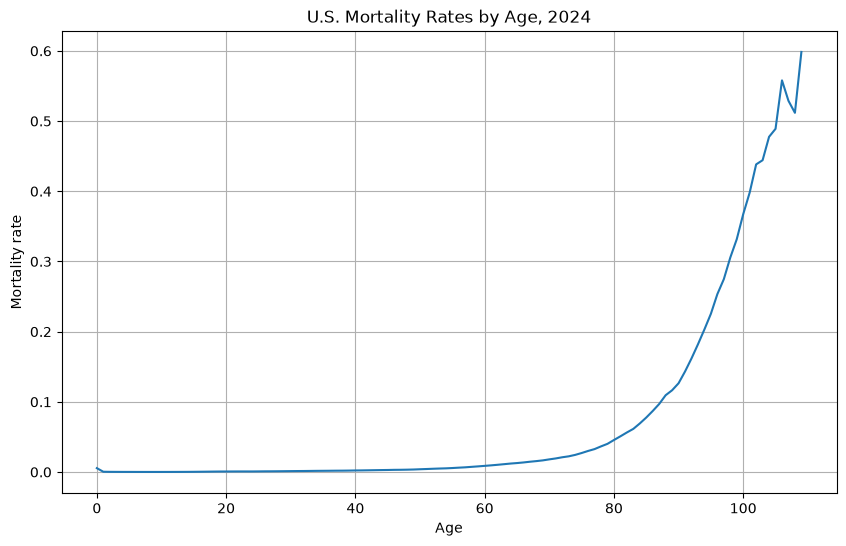

In [57]:
mortality_2024 = df_2024[df_2024["Age"] != "110+"].copy()

mortality_2024["Age"] = mortality_2024["Age"].astype(int)

plt.figure(figsize=(10, 6))
plt.plot(mortality_2024["Age"], mortality_2024["Total"])
plt.xlabel("Age")
plt.ylabel("Mortality rate")
plt.title("U.S. Mortality Rates by Age, 2024")
plt.grid(True)
plt.savefig(
    "../results/figures/mortality_curve_2024_log.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [58]:
mortality_2024["log_mortality"] = np.log(mortality_2024["Total"])
mortality_2024 = df_2024[df_2024["Age"] != "110+"].copy()

mortality_2024["Age"] = mortality_2024["Age"].astype(int)

mortality_2024["log_mortality"] = np.log(
    mortality_2024["Total"]
)

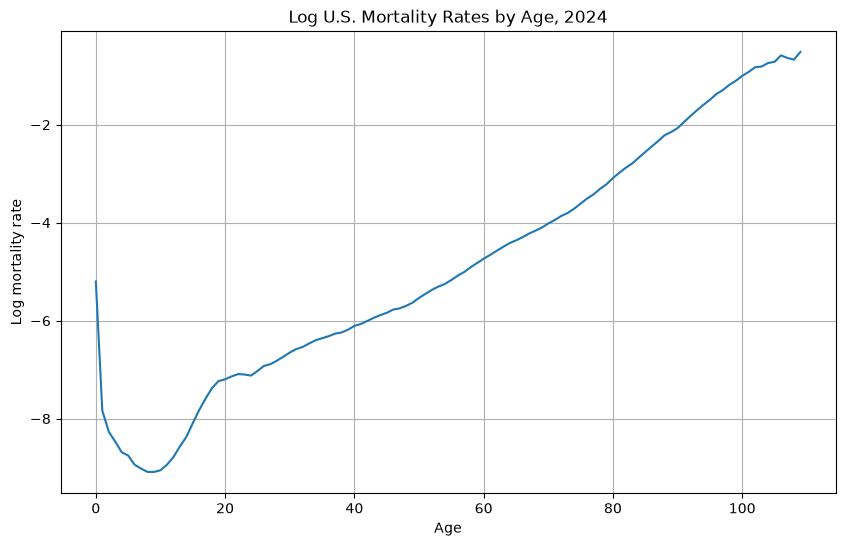

In [59]:
plt.figure(figsize=(10, 6))

plt.plot(
    mortality_2024["Age"],
    mortality_2024["log_mortality"]
)

plt.xlabel("Age")
plt.ylabel("Log mortality rate")
plt.title("Log U.S. Mortality Rates by Age, 2024")
plt.grid(True)

plt.show()

## Cubic Spline Interpolation

In [60]:
from scipy.interpolate import CubicSpline
x = mortality_2024["Age"].values
y = mortality_2024["log_mortality"].values

spline = CubicSpline(x, y)

In [61]:
age_smooth = np.linspace(x.min(), x.max(), 500)

log_mortality_smooth = spline(age_smooth)

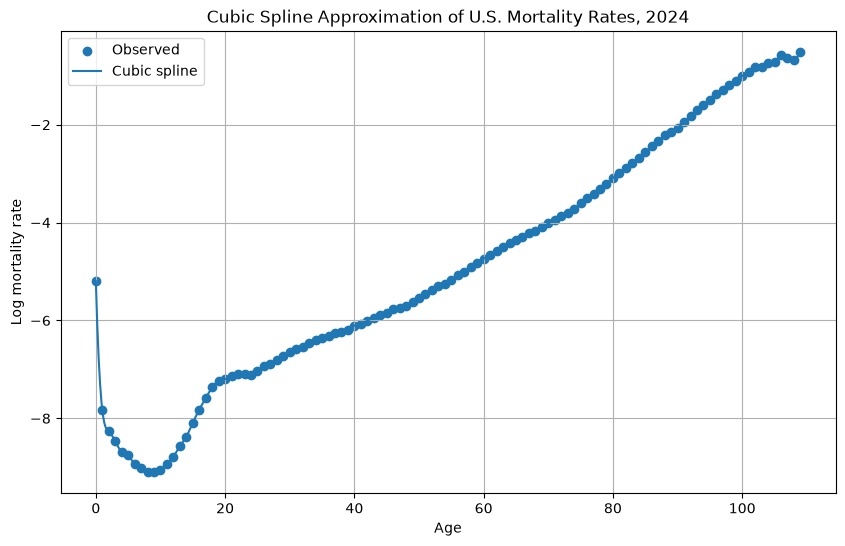

In [62]:
plt.figure(figsize=(10, 6))

plt.scatter(
    x,
    y,
    label="Observed"
)

plt.plot(
    age_smooth,
    log_mortality_smooth,
    label="Cubic spline"
)

plt.xlabel("Age")
plt.ylabel("Log mortality rate")
plt.title("Cubic Spline Approximation of U.S. Mortality Rates, 2024")
plt.legend()
plt.grid(True)
plt.savefig(
    "../results/figures/spline_2024.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [63]:
age = 37.5

estimated_log_mortality = spline(age)

print("Estimated log mortality:", estimated_log_mortality)

Estimated log mortality: -6.252450840641193


In [64]:
estimated_mortality = np.exp(estimated_log_mortality)

print("Estimated mortality rate:", estimated_mortality)

Estimated mortality rate: 0.0019257286937931946


### estimated 2024 mortality rate at age 37.5 is about 0.1926%

In [65]:
print(mortality_2024[
    mortality_2024["Age"].isin([36, 37, 38, 39])
][["Age", "Total"]])

       Age     Total
10137   36  0.001804
10138   37  0.001901
10139   38  0.001948
10140   39  0.002060


## Least-Squares Polynomial Approximation

In [66]:
from numpy.polynomial import Polynomial
x = mortality_2024["Age"].values
y = mortality_2024["log_mortality"].values

polynomial = Polynomial.fit(x, y, 5)

log_mortality_poly = polynomial(x)

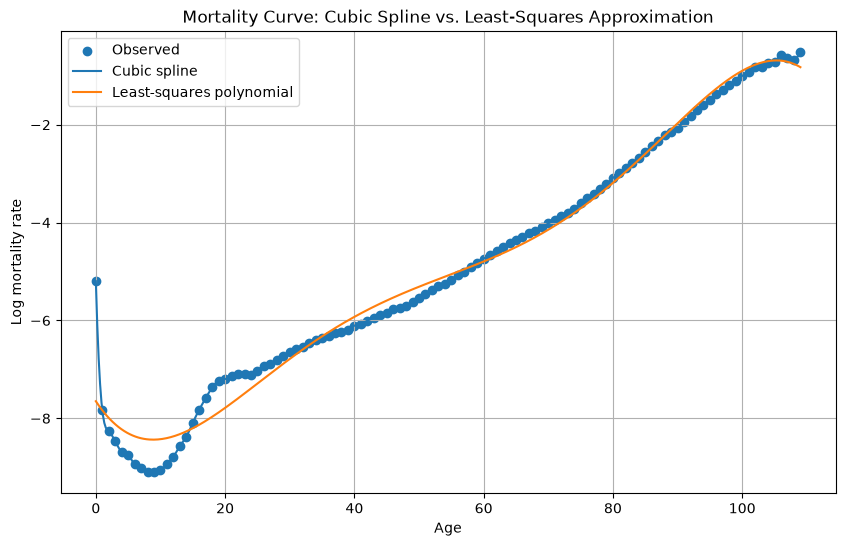

In [67]:
plt.figure(figsize=(10, 6))

plt.scatter(
    x,
    y,
    label="Observed"
)

plt.plot(
    age_smooth,
    log_mortality_smooth,
    label="Cubic spline"
)

plt.plot(
    age_smooth,
    polynomial(age_smooth),
    label="Least-squares polynomial"
)

plt.xlabel("Age")
plt.ylabel("Log mortality rate")
plt.title("Mortality Curve: Cubic Spline vs. Least-Squares Approximation")
plt.legend()
plt.grid(True)

plt.savefig(
    "../results/figures/spline_vs_polynomial_2024.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Numerical Method Comparison 
### To compare the numerical methods fairly, the 2024 mortality observations were divided into training and testing sets based on age. Even ages were used to fit each model, while odd ages were reserved for testing. This evaluates how well each method estimates mortality at ages that were not directly used during fitting.
Cubic spline:
RMSE = 0.1010
MAE  = 0.0336

Degree-5 polynomial:
RMSE = 0.3126
MAE  = 0.2418

In [68]:
from sklearn.metrics import mean_squared_error

rmse_polynomial = np.sqrt(
    mean_squared_error(y, log_mortality_poly)
)

print("Least-squares polynomial RMSE:", rmse_polynomial)

Least-squares polynomial RMSE: 0.34399554117559983


### The fitted degree-5 polynomial's predictions differ from the observed log mortality rate by about 0.344 units on average in terms of the root mean squeared error.

In [69]:
train = mortality_2024[mortality_2024["Age"] % 2 == 0].copy()
test = mortality_2024[mortality_2024["Age"] % 2 == 1].copy()

In [70]:
x_train = train["Age"].values
y_train = train["log_mortality"].values

x_test = test["Age"].values
y_test = test["log_mortality"].values

In [71]:
spline_test = CubicSpline(x_train, y_train)
spline_predictions = spline_test(x_test)
rmse_spline = np.sqrt(
    mean_squared_error(y_test, spline_predictions)
)

print("Cubic spline test RMSE:", rmse_spline)

Cubic spline test RMSE: 0.10097156126403455


In [72]:
polynomial_test = Polynomial.fit(x_train, y_train, 5)

In [73]:
polynomial_predictions = polynomial_test(x_test)

In [74]:
rmse_polynomial_test = np.sqrt(
    mean_squared_error(y_test, polynomial_predictions)
)

print("Least-squares polynomial test RMSE:", rmse_polynomial_test)

Least-squares polynomial test RMSE: 0.31257760878883656


### Cubic Spline adaps to local changes in the mortality curve better than polynomial that has one global equation - Spline has a smaller test error on log mortility scale

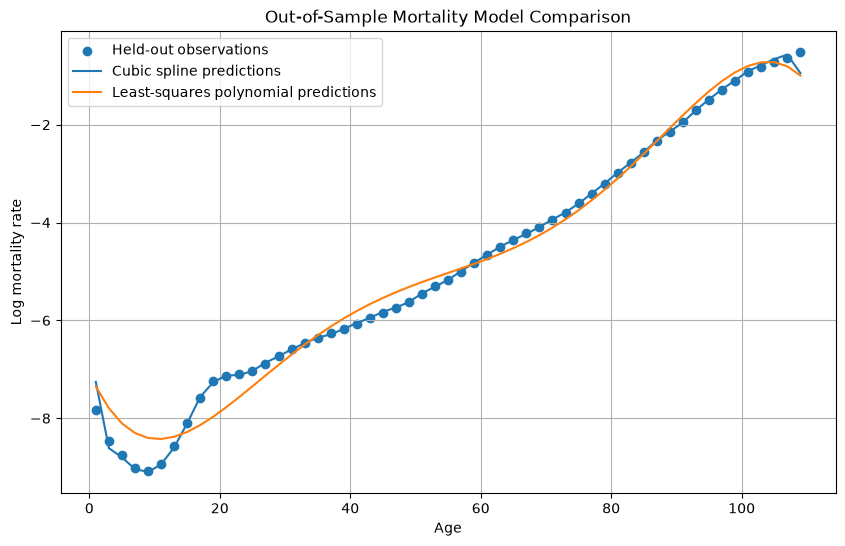

In [75]:
plt.figure(figsize=(10, 6))

plt.scatter(
    x_test,
    y_test,
    label="Held-out observations"
)

plt.plot(
    x_test,
    spline_predictions,
    label="Cubic spline predictions"
)

plt.plot(
    x_test,
    polynomial_predictions,
    label="Least-squares polynomial predictions"
)

plt.xlabel("Age")
plt.ylabel("Log mortality rate")
plt.title("Out-of-Sample Mortality Model Comparison")
plt.legend()
plt.grid(True)

plt.savefig(
    "../results/figures/2020_vs_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [76]:
from sklearn.metrics import mean_absolute_error
mae_spline = mean_absolute_error(
    y_test,
    spline_predictions
)

print("Cubic spline test MAE:", mae_spline)

Cubic spline test MAE: 0.03356932713393714


In [77]:
mae_polynomial = mean_absolute_error(
    y_test,
    polynomial_predictions
)

print("Least-squares polynomial test MAE:", mae_polynomial)

Least-squares polynomial test MAE: 0.24182093373156144


### Smaller that RMSE, gives less weight to large errors
### on the held-out ages, the cubic spline produced smaller errors than the degree-5 polynomial for both measures

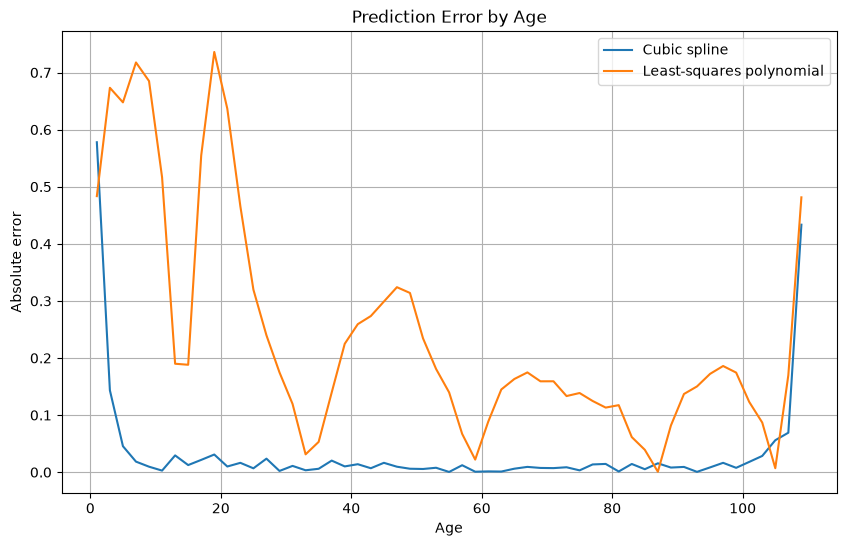

In [78]:
spline_errors = np.abs(y_test - spline_predictions)
polynomial_errors = np.abs(y_test - polynomial_predictions)
plt.figure(figsize=(10, 6))

plt.plot(
    x_test,
    spline_errors,
    label="Cubic spline"
)

plt.plot(
    x_test,
    polynomial_errors,
    label="Least-squares polynomial"
)

plt.xlabel("Age")
plt.ylabel("Absolute error")
plt.title("Prediction Error by Age")
plt.legend()
plt.grid(True)

plt.savefig(
    "../results/figures/prediction_error_2020_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [79]:
print(pd.DataFrame({
    "Age": x_test,
    "Spline Error": spline_errors,
    "Polynomial Error": polynomial_errors
}).head(20))

    Age  Spline Error  Polynomial Error
0     1      0.577895          0.483497
1     3      0.143404          0.673273
2     5      0.045540          0.647745
3     7      0.018507          0.717651
4     9      0.009636          0.685075
5    11      0.002793          0.516515
6    13      0.029410          0.189948
7    15      0.012471          0.188156
8    17      0.021556          0.554859
9    19      0.030947          0.736038
10   21      0.009963          0.636623
11   23      0.016398          0.465725
12   25      0.006804          0.319717
13   27      0.023702          0.239726
14   29      0.002183          0.174732
15   31      0.011031          0.119597
16   33      0.003367          0.031264
17   35      0.005983          0.053078
18   37      0.020310          0.139505
19   39      0.010128          0.224904


In [80]:
print("Number of zero spline errors:",
      np.sum(np.isclose(spline_errors, 0)))

Number of zero spline errors: 0


In [81]:
mortality_2020 = df[df["Year"] == 2020].copy()

mortality_2020 = mortality_2020[mortality_2020["Age"] != "110+"].copy()
mortality_2020["Age"] = mortality_2020["Age"].astype(int)

mortality_2020.head()

,Year,Age,Female,Male,Total
9657,2020,0,0.004911,0.005850,0.005391
9658,2020,1,0.000320,0.000416,0.000369
9659,2020,2,0.000203,0.000264,0.000234
9660,2020,3,0.000163,0.000211,0.000188
9661,2020,4,0.000123,0.000155,0.000139


In [82]:
mortality_2020["log_mortality"] = np.log(mortality_2020["Total"])
mortality_2020 = df[df["Year"] == 2020].copy()

mortality_2020 = mortality_2020[
    mortality_2020["Age"] != "110+"
].copy()

mortality_2020["Age"] = mortality_2020["Age"].astype(int)

mortality_2020["log_mortality"] = np.log(
    mortality_2020["Total"]
)

## Cross-Year Predictions

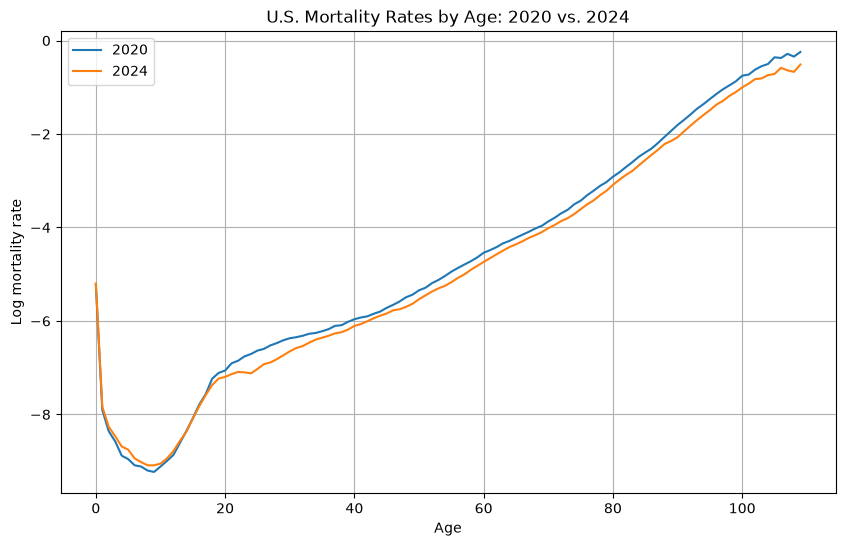

In [83]:
plt.figure(figsize=(10, 6))

plt.plot(
    mortality_2020["Age"],
    mortality_2020["log_mortality"],
    label="2020"
)

plt.plot(
    mortality_2024["Age"],
    mortality_2024["log_mortality"],
    label="2024"
)

plt.xlabel("Age")
plt.ylabel("Log mortality rate")
plt.title("U.S. Mortality Rates by Age: 2020 vs. 2024")
plt.legend()
plt.grid(True)

plt.show()

In [84]:

x_2020 = mortality_2020["Age"].values
y_2020 = mortality_2020["log_mortality"].values

spline_2020 = CubicSpline(x_2020, y_2020)

x_2024 = mortality_2024["Age"].values
y_2024 = mortality_2024["log_mortality"].values

spline_2024_predictions = spline_2020(x_2024)

In [85]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse_2020_to_2024 = np.sqrt(
    mean_squared_error(y_2024, spline_2024_predictions)
)

mae_2020_to_2024 = mean_absolute_error(
    y_2024, spline_2024_predictions
)

print("2020 → 2024 spline RMSE:", rmse_2020_to_2024)
print("2020 → 2024 spline MAE:", mae_2020_to_2024)

2020 → 2024 spline RMSE: 0.19903481854032604
2020 → 2024 spline MAE: 0.18256226782312276


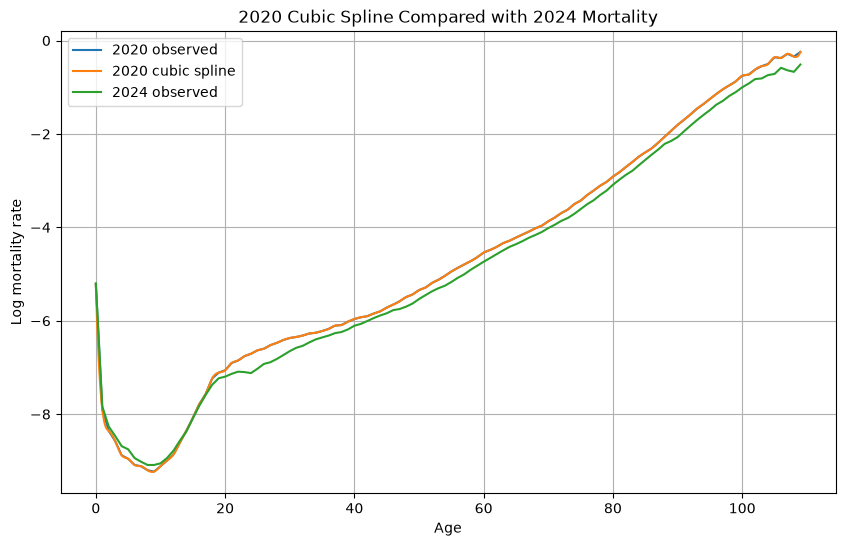

In [86]:
age_smooth = np.linspace(
    mortality_2020["Age"].min(),
    mortality_2020["Age"].max(),
    500
)

spline_smooth = spline_2020(age_smooth)

plt.figure(figsize=(10, 6))

plt.plot(
    mortality_2020["Age"],
    mortality_2020["log_mortality"],
    label="2020 observed"
)

plt.plot(
    age_smooth,
    spline_smooth,
    label="2020 cubic spline"
)

plt.plot(
    mortality_2024["Age"],
    mortality_2024["log_mortality"],
    label="2024 observed"
)

plt.xlabel("Age")
plt.ylabel("Log mortality rate")
plt.title("2020 Cubic Spline Compared with 2024 Mortality")
plt.legend()
plt.grid(True)

plt.show()

In [87]:
polynomial_2020 = Polynomial.fit(
    x_2020,
    y_2020,
    5
)
polynomial_2024_predictions = polynomial_2020(x_2024)
rmse_polynomial_2020_to_2024 = np.sqrt(
    mean_squared_error(y_2024, polynomial_2024_predictions)
)

mae_polynomial_2020_to_2024 = mean_absolute_error(
    y_2024,
    polynomial_2024_predictions
)

print(
    "2020 → 2024 polynomial RMSE:",
    rmse_polynomial_2020_to_2024
)

print(
    "2020 → 2024 polynomial MAE:",
    mae_polynomial_2020_to_2024
)


2020 → 2024 polynomial RMSE: 0.3911134241751403
2020 → 2024 polynomial MAE: 0.2691267114648012


### To examine whether the numerical methods could approximate mortality rates across different years, a cubic spline and degree-5 least-squares polynomial were fitted using the 2020 U.S. mortality curve. The resulting models were then evaluated against the observed 2024 mortality curve
Cubic spline:
RMSE = 0.1990
MAE  = 0.1826

Degree-5 polynomial:
RMSE = 0.3911
MAE  = 0.2691

## Error Analysis

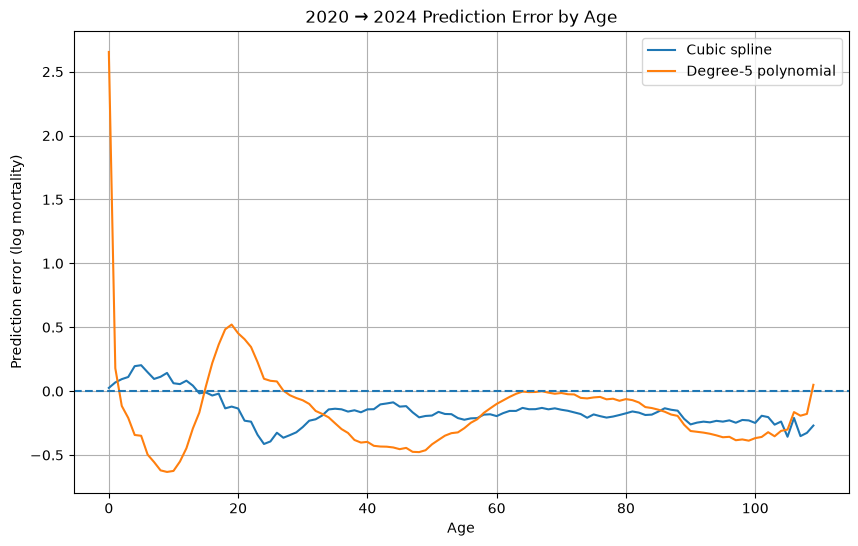

In [88]:
spline_errors_2020_2024 = (
    y_2024 - spline_2024_predictions
)

polynomial_errors_2020_2024 = (
    y_2024 - polynomial_2024_predictions
)

plt.figure(figsize=(10, 6))

plt.plot(
    x_2024,
    spline_errors_2020_2024,
    label="Cubic spline"
)

plt.plot(
    x_2024,
    polynomial_errors_2020_2024,
    label="Degree-5 polynomial"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Age")
plt.ylabel("Prediction error (log mortality)")
plt.title("2020 → 2024 Prediction Error by Age")
plt.legend()
plt.grid(True)


plt.show()

### The results indicate that the cubic spline provided a closer approximation to the observed mortality data for both evaluation experiments. However, these results apply specifically to the U.S. mortality data and validation procedures used in this project and do not establish that cubic splines will outperform polynomial approximation in all mortality-modeling applications.

## 9. Actuarial Interpretation

### Mortality modeling is an important component of actuarial analysis because mortality assumptions can be used to estimate the likelihood and timing of future deaths within a population.

This project demonstrates several numerical techniques that are relevant to
actuarial work:

- Mortality curves: Age-specific mortality rates provide a way to
  characterize how mortality changes across a population's lifetime.

- Interpolation: Cubic spline interpolation can estimate mortality rates
  at ages between observed data points while allowing the curve to adapt to
  local changes in mortality.

- Least-squares approximation: Polynomial least-squares approximation
  provides a single mathematical function that summarizes the overall
  relationship between age and mortality.

- Model comparison: RMSE and MAE were used to compare how closely the
  numerical methods approximated observations that were not used during
  fitting.

- Mortality trends: Comparing the 2020 and 2024 mortality curves
  demonstrates that mortality depends not only on age but can also change
  over time. A model intended for long-term mortality projection would
  therefore need to account for both age and calendar-year effects.

These techniques have potential applications in areas such as life insurance,annuities, pension planning, and longevity-risk analysis. In practice, actuaries would typically use more sophisticated mortality models and additional assumptions when developing mortality projections for pricing or valuation.

## 10. Limitations

### Several limitations should be considered when interpreting the results of this analysis.
- Single population:** The analysis uses mortality data for the United
  States. Results may differ for other countries or populations.

- Single-year mortality curves:** Much of the analysis focuses on the
  2024 mortality curve. Mortality patterns can change over time, so a
  single-year curve does not represent a long-term mortality projection.

- Cross-year prediction: The 2020 → 2024 analysis evaluates how well
  mortality information from 2020 approximates mortality in 2024. It does
  not constitute a complete mortality forecasting model because it does
  not explicitly model the time trend between the two years.

- Interpolation versus forecasting: Cubic spline interpolation is
  particularly suited to estimating values between observed ages. Using a
  spline fitted to one year to estimate another year is a different task
  and introduces additional error.

- Polynomial degree: The least-squares comparison uses a degree-5
  polynomial. Other polynomial degrees or approximation methods could
  produce different results.

- Infant mortality: Mortality changes especially rapidly between
  infancy and early childhood. This makes the youngest ages more difficult
  to approximate using models trained on a subset of ages.

- *ortality measure: The dataset contains age-specific mortality rates,
  rather than individual-level death probabilities. The rates therefore
  should not be interpreted directly as the probability that an individual
  will die at a particular age.

- Limited model complexity: A practical actuarial mortality projection
  would generally incorporate additional factors, such as calendar-year
  trends, cohort effects, and potentially separate mortality assumptions
  for different populations.

## 11. Conclusion

This project applied numerical methods to U.S. age-specific mortality data to investigate how different mathematical approaches can represent mortality curves.

Cubic spline interpolation and a degree-5 least-squares polynomial were evaluated using two experiments. In the first experiment, even ages were used for fitting and odd ages were used for testing. The cubic spline achieved a test RMSE of 0.1010 and MAE of 0.0336, compared with 0.3126 RMSE and 0.2418 MAE for the degree-5 polynomial.

A second experiment used the 2020 mortality curve to approximate mortality rates in 2024. The cubic spline produced an RMSE of 0.1990 and MAE of 0.1826, while the degree-5 polynomial produced an RMSE of 0.3911 and MAE of 0.2691.

For the data and evaluation procedures used in this project, the cubic spline provided a closer approximation to the observed mortality rates than the degree-5 polynomial. The results also demonstrated that accurately describing the shape of a mortality curve is different from forecasting how mortality will change over time.

Overall, the project provided practical experience implementing numerical methods in Python, evaluating approximation error, and interpreting mathematical models in an actuarial context. More advanced mortality projection methods could extend this work by explicitly modeling calendar year, cohort effects, and long-term mortality trends.